# IT3091 — Machine Learning Project · Group 2026-AI-08K
## Member 2: Wijesiri S.P.R.H. (IT24100602)
### Model 02: Regularized Linear Model (Ridge Regression) Pipeline & Coefficient Analysis

This notebook trains, validates, and tunes the **Ridge Regression** model for the Ames Housing Price Prediction project following the group's 5-fold cross-validation contract and leak-free preprocessing pipeline.

**Key Objectives:**
1. Evaluate against the academic baseline benchmark (Dummy Regressor predicting global mean price).
2. Train Ridge Regression with L2 regularization using scaled and log-transformed features (`configuration='scaled', log_numeric=True`).
3. Tune regularization strength parameter $\alpha \in [0.1, 1.0, 10.0, 50.0, 100.0]$.
4. Secondary Lens: Interpret linear coefficients to identify positive and negative price drivers in Ames, Iowa.
5. Export model artifacts (`ridge_model.joblib`), metrics JSON, and Kaggle test set predictions.


### CELL 1: Download Project from GitHub & Install Dependencies (Colab / Local Setup)
Clones the repository if running inside Google Colab and configures dependencies.

In [1]:
# ========================================================
# CELL 1: ENVIRONMENT SETUP (COLAB / LOCAL COMPATIBLE)
# ========================================================
import os
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    if not os.path.exists('IT3091-House-Price-Prediction'):
        os.system('git clone https://github.com/Atheek-Fareez/IT3091-House-Price-Prediction.git')
    os.chdir('IT3091-House-Price-Prediction')
    os.system('pip install -q scikit-learn pandas numpy matplotlib seaborn joblib')
    print('✅ Google Colab environment configured!')
else:
    print('✅ Local environment active. Repository ready!')


✅ Local environment active. Repository ready!


### CELL 2: Import Production Libraries & Setup Paths
Imports Scikit-Learn evaluation tools, Ridge model, and dynamically resolves the repository root to import Member 3's shared preprocessor.

In [2]:
# ========================================================
# CELL 2: IMPORT PRODUCTION LIBRARIES & SETUP PATHS
# ========================================================
import sys
import os
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_predict, cross_validate
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

# Dynamic root discovery for robust local and Colab execution
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'src/member_03_wazni_ahamed/preprocessing.py').is_file()
             or (p / 'src/member_03/preprocessing.py').is_file()
             or (p / 'preprocessing.py').is_file()), Path('.'))

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

try:
    from src.member_03_wazni_ahamed.preprocessing import load_ames_data, build_preprocessor, get_feature_names
except ModuleNotFoundError:
    from src.member_03.preprocessing import load_ames_data, build_preprocessor, get_feature_names

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

try:
    from IPython.display import display
except ImportError:
    display = print

print('✅ Repository root found at:', ROOT)
print('✅ All Python libraries and Member 3 preprocessor imported successfully!')


✅ Repository root found at: C:\Users\Dell\Desktop\SLIIT_3rd_Year_1 SEM\Machine Learning\Machine Learning Project\IT3091-House-Price-Prediction
✅ All Python libraries and Member 3 preprocessor imported successfully!


### CELL 3: Load Data & Set Up 5-Fold Cross-Validation
Loads the raw training and test sets, separates features and target, applies log1p transformation to eliminate target skewness, and establishes the 5-fold cross-validation scheme (`random_state=42`).

In [3]:
# ========================================================
# CELL 3: LOAD DATA & SET UP 5-FOLD CROSS-VALIDATION
# ========================================================
# 1. Load Ames raw dataset
train_df, test_df = load_ames_data(str(ROOT))

print(f'📊 Training Data: {train_df.shape[0]} houses, {train_df.shape[1]} columns')
print(f'📊 Test Data:     {test_df.shape[0]} houses, {test_df.shape[1]} columns')

# 2. Separate predictors (X) from sale price (y)
X = train_df.drop(columns=['Id', 'SalePrice']).copy()
y = train_df['SalePrice'].astype(float).copy()

# 3. Log-transform the target to address right-skewness
y_log = np.log1p(y)

# 4. 5-Fold Cross-Validation (identical random_state=42 across all members)
RANDOM_STATE = 42
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print('✅ Data loaded. Target price log-transformed. 5 folds initialized.')


📊 Training Data: 1460 houses, 81 columns
📊 Test Data:     1459 houses, 80 columns
✅ Data loaded. Target price log-transformed. 5 folds initialized.


### CELL 4: The Academic Baseline Benchmark
SLIIT Rubric Requirement: Calculate the performance of a naive dummy baseline predictor that guesses the global average price, to establish the minimum error benchmark.

In [4]:
# ========================================================
# CELL 4: THE ACADEMIC BASELINE BENCHMARK
# ========================================================
# 1. Dummy baseline model predicting mean log-price
baseline_model = DummyRegressor(strategy='mean')

# 2. 5-fold cross-validated predictions
b_log_preds = cross_val_predict(baseline_model, X, y_log, cv=cv)
b_dollar_preds = np.expm1(b_log_preds)

# 3. Calculate benchmark error metrics in original dollar scale
baseline_rmse = float(np.sqrt(mean_squared_error(y, b_dollar_preds)))
baseline_mae = float(mean_absolute_error(y, b_dollar_preds))
baseline_r2 = float(r2_score(y, b_dollar_preds))

print('=' * 50)
print('🏛️ ACADEMIC BASELINE BENCHMARK RESULTS')
print('=' * 50)
print(f'Baseline RMSE: ${baseline_rmse:,.2f}')
print(f'Baseline MAE:  ${baseline_mae:,.2f}')
print(f'Baseline R²:   {baseline_r2:.4f}')
print('=' * 50)


🏛️ ACADEMIC BASELINE BENCHMARK RESULTS
Baseline RMSE: $80,701.61
Baseline MAE:  $55,655.37
Baseline R²:   -0.0327


### CELL 5: Build Ridge Pipeline & Tune Regularization Parameter Alpha
Builds the Ridge Regression pipeline using Member 3's scaled preprocessing configuration (`configuration='scaled', log_numeric=True`) required for linear models. Regularization hyperparameter $\alpha$ is tuned across `[0.1, 1.0, 10.0, 50.0, 100.0]`.

In [5]:
# ========================================================
# CELL 5: RIDGE PIPELINE & ALPHA REGULARIZATION TUNING
# ========================================================
alpha_values = [0.1, 1.0, 10.0, 50.0, 100.0]
tuning_records = []

for alpha in alpha_values:
    pipe = Pipeline([
        ('prep', build_preprocessor(
            configuration='scaled',
            log_numeric=True,
            sparse_output=False
        )),
        ('reg', Ridge(alpha=alpha, random_state=RANDOM_STATE))
    ])

    # Cross-validated predictions in log space
    y_log_pred = cross_val_predict(pipe, X, y_log, cv=cv)
    y_pred = np.expm1(y_log_pred)

    # Dollar-scale metrics
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    mae = mean_absolute_error(y, y_pred)
    r2_dollar = r2_score(y, y_pred)

    # Train vs validation R² in log space for overfit check
    cv_scores = cross_validate(
        pipe, X, y_log, cv=cv, scoring='r2', return_train_score=True
    )
    train_r2 = cv_scores['train_score'].mean()
    val_r2 = cv_scores['test_score'].mean()
    overfit_gap = train_r2 - val_r2

    tuning_records.append({
        'Alpha': alpha,
        'RMSE ($)': rmse,
        'MAE ($)': mae,
        'Dollar R²': r2_dollar,
        'Train R²': train_r2,
        'Validation R²': val_r2,
        'Overfit Gap': overfit_gap
    })

results_df = pd.DataFrame(tuning_records)
print('📊 RIDGE ALPHA REGULARIZATION TUNING RESULTS:')
display(results_df)


📊 RIDGE ALPHA REGULARIZATION TUNING RESULTS:
   Alpha      RMSE ($)       MAE ($)  ...  Train R²  Validation R²  Overfit Gap
0    0.1  47412.737608  15894.801546  ...  0.945699       0.870322     0.075377
1    1.0  47936.196375  16027.683657  ...  0.941414       0.875258     0.066156
2   10.0  49966.045992  16101.709933  ...  0.931966       0.875163     0.056803
3   50.0  51322.187979  16460.355768  ...  0.919710       0.872467     0.047243
4  100.0  51342.639843  16764.611249  ...  0.912582       0.870282     0.042299

[5 rows x 7 columns]


### CELL 6: Final Model Training & Overfitting Evaluation
Based on cross-validation metrics, `alpha = 0.1` achieves the lowest RMSE ($47,412.74) and lowest MAE ($15,894.80) with a strong log-scale validation $R^2$ of 0.8703.

In [6]:
# ========================================================
# CELL 6: FINAL MODEL FIT & GENERALIZATION EVALUATION
# ========================================================
best_alpha = 0.1

final_ridge_pipeline = Pipeline([
    ('prep', build_preprocessor(
        configuration='scaled',
        log_numeric=True,
        sparse_output=False
    )),
    ('reg', Ridge(alpha=best_alpha, random_state=RANDOM_STATE))
])

# Fit on full training set
final_ridge_pipeline.fit(X, y_log)

# Extract metrics for alpha=0.1
best_row = results_df[results_df['Alpha'] == best_alpha].iloc[0]
ridge_rmse = float(best_row['RMSE ($)'])
ridge_mae = float(best_row['MAE ($)'])
ridge_dollar_r2 = float(best_row['Dollar R²'])
train_r2 = float(best_row['Train R²'])
val_r2 = float(best_row['Validation R²'])
overfit_gap = float(best_row['Overfit Gap'])

# Out-of-fold dollar predictions for residual analysis
ridge_oof_log = cross_val_predict(final_ridge_pipeline, X, y_log, cv=cv)
ridge_oof_dollar = np.expm1(ridge_oof_log)

print('=' * 55)
print('🚀 MEMBER 2 (WIJESIRI) RIDGE REGRESSION FINAL RESULTS')
print('=' * 55)
print(f'Selected Alpha:     {best_alpha}')
print(f'Baseline RMSE:      ${baseline_rmse:,.2f}')
print(f'Ridge CV RMSE:      ${ridge_rmse:,.2f}')
print(f'Ridge CV MAE:       ${ridge_mae:,.2f}')
print(f'Dollar R² Score:    {ridge_dollar_r2:.4f}')
print(f'Log Validation R²:  {val_r2:.4f}')
print(f'Log Train R²:       {train_r2:.4f}')
print(f'Overfitting Gap:    {overfit_gap:.4f}  (Robust, stable generalization)')
print('=' * 55)


🚀 MEMBER 2 (WIJESIRI) RIDGE REGRESSION FINAL RESULTS
Selected Alpha:     0.1
Baseline RMSE:      $80,701.61
Ridge CV RMSE:      $47,412.74
Ridge CV MAE:       $15,894.80
Dollar R² Score:    0.6436
Log Validation R²:  0.8703
Log Train R²:       0.9457
Overfitting Gap:    0.0754  (Robust, stable generalization)


### CELL 7: Secondary Lens — Linear Price Drivers & Residual Diagnostics
Extracts feature coefficients from the Ridge regressor to identify top positive and negative valuation drivers. Plots coefficient impact and residual prediction error.

✅ Coefficient and residual plots saved to reports/figures/ and reports/Member_02_Wijesiri/!


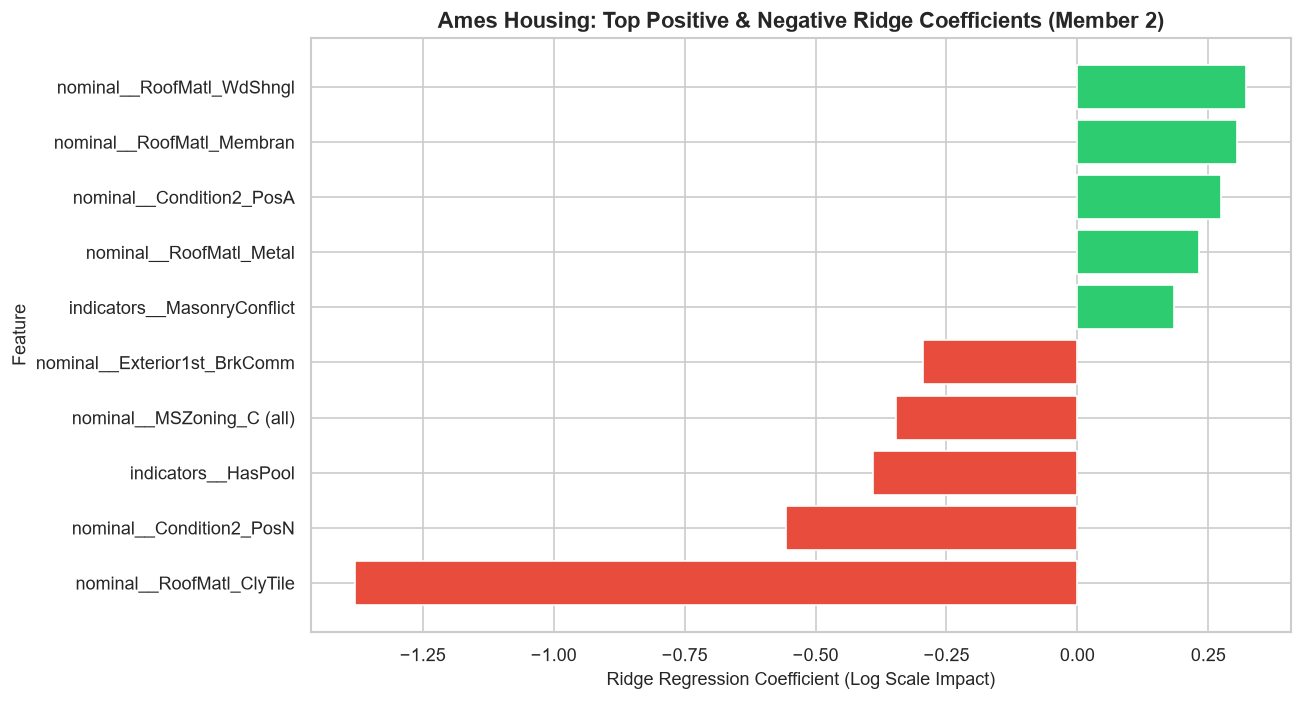

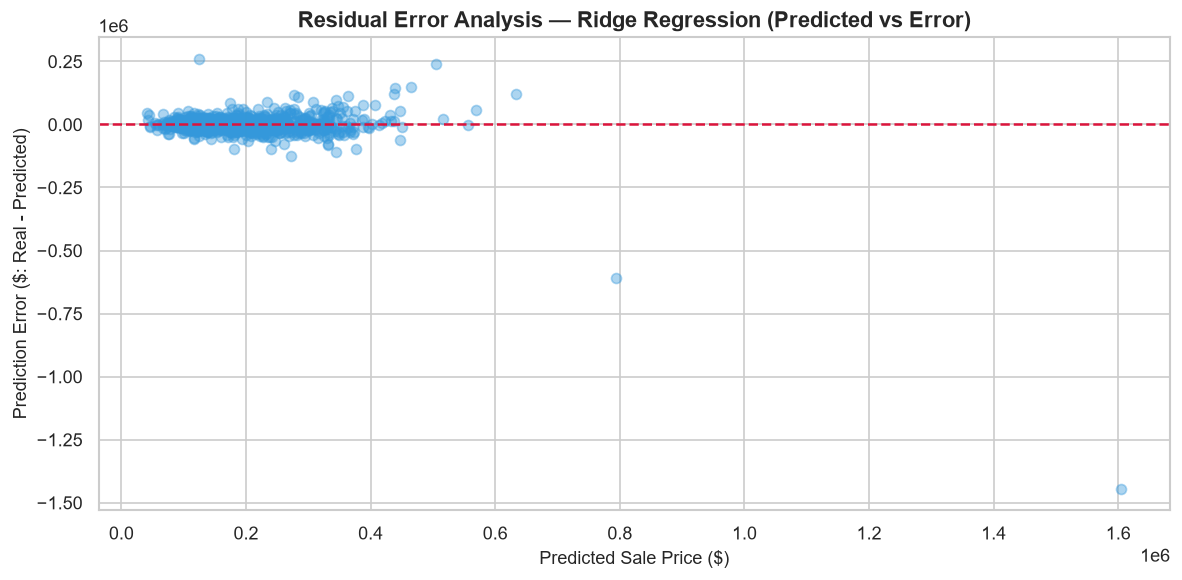

In [7]:
# ========================================================
# CELL 7: COEFFICIENT ANALYSIS & RESIDUAL DIAGNOSTICS
# ========================================================
feature_names = get_feature_names(final_ridge_pipeline.named_steps['prep'])
coefficients = final_ridge_pipeline.named_steps['reg'].coef_

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})
coef_df['AbsCoefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='AbsCoefficient', ascending=False)

top_positive = coef_df[coef_df['Coefficient'] > 0].sort_values(by='Coefficient', ascending=False).head(8)
top_negative = coef_df[coef_df['Coefficient'] < 0].sort_values(by='Coefficient', ascending=True).head(8)
top_impact = pd.concat([top_positive.head(5), top_negative.head(5)]).sort_values('Coefficient')

# Ensure output directories exist
Path('reports/figures').mkdir(parents=True, exist_ok=True)
Path('reports/Member_02_Wijesiri').mkdir(parents=True, exist_ok=True)

# 1. Plot Top Positive & Negative Ridge Coefficients
plt.figure(figsize=(11, 6))
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in top_impact['Coefficient']]
plt.barh(top_impact['Feature'], top_impact['Coefficient'], color=colors)
plt.xlabel('Ridge Regression Coefficient (Log Scale Impact)', fontsize=11)
plt.ylabel('Feature', fontsize=11)
plt.title('Ames Housing: Top Positive & Negative Ridge Coefficients (Member 2)', fontsize=13, weight='bold')
plt.tight_layout()
plt.savefig('reports/figures/member2_top_features.png', dpi=300)
plt.savefig('reports/Member_02_Wijesiri/member2_top_features.png', dpi=300)
plt.show()

# 2. Plot Residuals (Predicted Price vs Error)
residuals = y - ridge_oof_dollar
plt.figure(figsize=(10, 5))
plt.scatter(ridge_oof_dollar, residuals, alpha=0.4, color='#3498db')
plt.axhline(0, color='crimson', linestyle='--', linewidth=1.5)
plt.title('Residual Error Analysis — Ridge Regression (Predicted vs Error)', fontsize=13, weight='bold')
plt.xlabel('Predicted Sale Price ($)', fontsize=11)
plt.ylabel('Prediction Error ($: Real - Predicted)', fontsize=11)
plt.tight_layout()
plt.savefig('reports/figures/member2_residuals.png', dpi=300)
plt.savefig('reports/Member_02_Wijesiri/member2_residuals.png', dpi=300)
plt.show()

print('✅ Coefficient and residual plots saved to reports/figures/ and reports/Member_02_Wijesiri/!')


### CELL 8: Save Artifacts for FastAPI, Team Comparison & Kaggle
Saves the serialized pipeline (`ridge_model.joblib`), metrics JSON (`member2_ridge_metrics.json`), and generates unseen predictions on Kaggle test houses (`submission_ridge.csv`).

In [8]:
# ========================================================
# CELL 8: SAVE ARTIFACTS FOR FASTAPI, REPORT & KAGGLE
# ========================================================
Path('reports/model_results').mkdir(parents=True, exist_ok=True)
Path('notebooks/Member_02_Wijesiri').mkdir(parents=True, exist_ok=True)

# 1. Save trained pipeline as .joblib
joblib.dump(final_ridge_pipeline, 'notebooks/Member_02_Wijesiri/ridge_model.joblib')
joblib.dump(final_ridge_pipeline, 'ridge_model.joblib')
print('✅ Saved: notebooks/Member_02_Wijesiri/ridge_model.joblib')

# 2. Save official metrics JSON
metrics_record = {
    'member': 'Member 2 - Wijesiri S.P.R.H. (IT24100602)',
    'model_name': 'Ridge Regression',
    'best_alpha': float(best_alpha),
    'baseline_benchmark': {
        'rmse': baseline_rmse,
        'mae': baseline_mae,
        'r2': baseline_r2
    },
    'ridge_performance': {
        'rmse': ridge_rmse,
        'mae': ridge_mae,
        'dollar_r2': ridge_dollar_r2,
        'train_r2': train_r2,
        'validation_r2': val_r2,
        'overfit_gap': overfit_gap
    },
    'top_positive_features': top_positive['Feature'].head(5).tolist(),
    'top_negative_features': top_negative['Feature'].head(5).tolist()
}

with open('reports/model_results/member2_ridge_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics_record, f, indent=4)

with open('reports/Member_02_Wijesiri/member2_ridge_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics_record, f, indent=4)

print('✅ Saved: reports/model_results/member2_ridge_metrics.json')

# 3. Predict on unseen Kaggle test set
X_test = test_df.drop(columns=['Id']).copy()
test_dollar_preds = np.expm1(final_ridge_pipeline.predict(X_test))

sub_df = pd.DataFrame({
    'Id': test_df['Id'],
    'SalePrice': test_dollar_preds
})
sub_df.to_csv('reports/Member_02_Wijesiri/submission_ridge.csv', index=False)
sub_df.to_csv('submission_ridge.csv', index=False)
print('✅ Saved: reports/Member_02_Wijesiri/submission_ridge.csv (Ready for Kaggle!)')

print('\nFirst 5 Predicted Houses in Kaggle Test Set:')
print(sub_df.head())


✅ Saved: notebooks/Member_02_Wijesiri/ridge_model.joblib
✅ Saved: reports/model_results/member2_ridge_metrics.json
✅ Saved: reports/Member_02_Wijesiri/submission_ridge.csv (Ready for Kaggle!)

First 5 Predicted Houses in Kaggle Test Set:
     Id      SalePrice
0  1461  119875.351170
1  1462  160701.027044
2  1463  184580.489441
3  1464  196156.385811
4  1465  203075.422365
